In [1]:
import pandas as pd
import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
data_ref = 'C:/Users/gerso/FBR/predictive/tatoeba-de-en/data/raw/comet/train_predictive_ancestral_scores_10_100.parquet'

In [9]:
df = pd.read_parquet(data_ref)

In [11]:
print(df["utilities"])

0        [[0.9753887, 0.7848192, 0.83554834, 0.7282275,...
1        [[0.8165607, 0.9719519, 0.845869, 0.80978024, ...
2        [[-0.21317534, -0.19443351, -0.9730543, -0.061...
3        [[0.78696823, 0.70679563, 0.6402663, 0.7804684...
4        [[1.1355082, 0.37553227, 1.063088, 1.0544952, ...
                               ...                        
20733    [[0.93995106, 1.1024798, 0.7764002, 0.6368107,...
20734      [[1.1940094, 0.8638255], [0.890753, 1.1595058]]
20735    [[0.9653103, 0.86437273, 0.81489, 0.91930693, ...
20736    [[1.0227203, 0.80961424, 0.7095283, 0.32444283...
20737    [[0.5720755, 0.83843684, 0.67052335, -1.111598...
Name: utilities, Length: 20738, dtype: object


In [26]:
import numpy as np
def get_max(x):
    maxes = []
    for utils in x["utilities"]:
        maxes.append(np.max(utils))
    
    return np.max(utils)

df["max_util"] = df.apply(get_max, axis=1)

In [28]:
def get_min(x):
    maxes = []
    for utils in x["utilities"]:
        maxes.append(np.min(utils))
    
    return np.min(utils)

df["min_util"] = df.apply(get_min, axis=1)

In [29]:
df["max_util"].max()

1.3706083

In [30]:
df["min_util"].min()

-2.2938428

In [4]:
from utilities.factories.PreprocessFactory import PreprocessFactory
# Next we preprocess the data
preprocess_factory = PreprocessFactory({
    "name": "basic"
})

preprocessor = preprocess_factory.get_preprocessor()


C:\Users\gerso\anaconda3\envs\thesis\lib\site-packages\tqdm\auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df, _ = preprocessor(df)

In [6]:
df["utility"].describe()

count     118535.000000
unique    118535.000000
top            0.906659
freq           1.000000
Name: utility, dtype: float64

In [7]:
print(df["utility"].min())
print(df["utility"].max())
print(df["utility"].mean())

-1.8110913670063018
1.3573256731033325
-0.029914182062810265


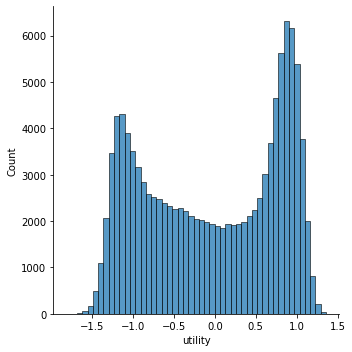

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.displot(data=df, x="utility")
